# SpatialData Crop Core Workflow with `Image2DModel` for `SLIDE-0329_crop_2048`

This notebook keeps the prototype focused on the core workflow:

1. lazily load the cropped full-merge OME-TIFF with `Image2DModel.parse(...)`
2. load the cell and nuclear masks as labels
3. vectorize cell labels with `spatialdata.to_polygons(...)`
4. aggregate image intensities by `cell_labels`
5. load the Nimbus crop table
6. inspect the image, labels, polygons, aggregation, and Nimbus table in a readable way
7. do a quick ID consistency check across masks, polygons, aggregation, and Nimbus


In [17]:
from __future__ import annotations

import os
import json
from pathlib import Path

os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/numba_cache")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig")

import anndata as ad
import dask.array as da
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spatialdata
import tifffile
from dask import delayed
from IPython.display import display
from shapely import make_valid
from spatialdata import SpatialData, aggregate, to_polygons
from spatialdata.models import Image2DModel, Labels2DModel, ShapesModel, TableModel

OUTPUTS_DIR = Path("/mnt/c/Analysis/Data_prototype/SLIDE-0329_crop_2048/outputs")
FULL_MERGE_PATH = OUTPUTS_DIR / "SLIDE-0329_crop_2048_full_merge.ome.tif"
CELL_MASK_PATH = OUTPUTS_DIR / "masks" / "SLIDE-0329_crop_2048_whole_cell.tiff"
NUCLEAR_MASK_PATH = OUTPUTS_DIR / "masks" / "SLIDE-0329_crop_2048_nuclear.tiff"
CHANNEL_MAP_PATH = OUTPUTS_DIR / "channel_map.generated.json"
NIMBUS_TABLE_PATH = Path("/mnt/c/Analysis/Data_prototype/nimbus_multislide/per_slide/SLIDE-0329_crop_2048/cell_table_full.csv")

required_paths = [FULL_MERGE_PATH, CELL_MASK_PATH, NUCLEAR_MASK_PATH, CHANNEL_MAP_PATH, NIMBUS_TABLE_PATH]
missing_paths = [str(path) for path in required_paths if not path.exists()]
assert not missing_paths, f"Missing required inputs: {missing_paths}"

print({"spatialdata": spatialdata.__version__, "outputs_dir": str(OUTPUTS_DIR)})


{'spatialdata': '0.7.2', 'outputs_dir': '/mnt/c/Analysis/Data_prototype/SLIDE-0329_crop_2048/outputs'}


## Lazy Image Load with `Image2DModel`


In [18]:
channel_map = json.loads(CHANNEL_MAP_PATH.read_text())
channel_aliases = [entry["alias"] for entry in channel_map]
CHUNK_SHAPE = (1, 256, 256)

with tifffile.TiffFile(FULL_MERGE_PATH) as tif:
    series = tif.series[0]
    series_shape = tuple(int(value) for value in series.shape)
    series_axes = series.axes
    level_shapes = [tuple(int(value) for value in level.shape[-2:]) for level in series.levels]
    level_axes = [level.axes for level in series.levels]
    level0_dtype_np = series.levels[0].dtype
    level0_dtype = str(level0_dtype_np)

assert series_shape[0] == len(channel_aliases), "Channel map length must match the OME-TIFF channel count"

def read_channel(channel_index: int):
    return tifffile.imread(FULL_MERGE_PATH, key=channel_index, level=0)

lazy_image_array = da.stack(
    [
        da.from_delayed(
            delayed(read_channel)(channel_index),
            shape=level_shapes[0],
            dtype=level0_dtype_np,
        )
        for channel_index in range(len(channel_aliases))
    ],
    axis=0,
).rechunk(CHUNK_SHAPE)

scale_factors = [
    {"y": current_shape[0] // next_shape[0], "x": current_shape[1] // next_shape[1]}
    for current_shape, next_shape in zip(level_shapes, level_shapes[1:])
]

full_image = Image2DModel.parse(
    lazy_image_array,
    dims=("c", "y", "x"),
    c_coords=channel_aliases,
    chunks=CHUNK_SHAPE,
    scale_factors=scale_factors,
)

scale0 = full_image["scale0"].image
print({
    "image_type": type(full_image).__name__,
    "series_shape": series_shape,
    "series_axes": series_axes,
    "ome_level_count": len(level_shapes),
    "level0_dtype": level0_dtype,
    "requested_chunks": CHUNK_SHAPE,
    "source_chunks": lazy_image_array.chunks,
    "scale0_chunks": scale0.chunks,
    "scale0_shape": tuple(scale0.shape),
    "first_channels": scale0.coords["c"].values[:5].tolist(),
})


{'image_type': 'DataTree', 'series_shape': (24, 2048, 2048), 'series_axes': 'CYX', 'ome_level_count': 8, 'level0_dtype': 'uint16', 'requested_chunks': (1, 256, 256), 'source_chunks': ((1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1), (256, 256, 256, 256, 256, 256, 256, 256), (256, 256, 256, 256, 256, 256, 256, 256)), 'scale0_chunks': ((1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1), (256, 256, 256, 256, 256, 256, 256, 256), (256, 256, 256, 256, 256, 256, 256, 256)), 'scale0_shape': (24, 2048, 2048), 'first_channels': ['R1_CY3_AF_I', 'R1_CY5_AF_I', 'R1_CY7_AF_I', 'R1_FITC_AF_I', 'R1_BIT2_RS0584_CY3B']}


In [20]:
lazy_image_array

dask.array<rechunk-merge, shape=(24, 2048, 2048), dtype=uint16, chunksize=(1, 256, 256), chunktype=numpy.ndarray>

In [28]:
full_image

<xarray.DataTree>
Group: /
├── Group: /scale0
│       Dimensions:  (c: 24, y: 2048, x: 2048)
│       Coordinates:
│         * c        (c) <U20 2kB 'R1_CY3_AF_I' 'R1_CY5_AF_I' ... 'R4_GFP_POLY_AF488'
│         * y        (y) float64 16kB 0.5 1.5 2.5 3.5 ... 2.046e+03 2.046e+03 2.048e+03
│         * x        (x) float64 16kB 0.5 1.5 2.5 3.5 ... 2.046e+03 2.046e+03 2.048e+03
│       Data variables:
│           image    (c, y, x) uint16 201MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
├── Group: /scale1
│       Dimensions:  (c: 24, y: 1024, x: 1024)
│       Coordinates:
│         * c        (c) <U20 2kB 'R1_CY3_AF_I' 'R1_CY5_AF_I' ... 'R4_GFP_POLY_AF488'
│         * y        (y) float64 8kB 1.0 3.0 5.0 7.0 ... 2.043e+03 2.045e+03 2.047e+03
│         * x        (x) float64 8kB 1.0 3.0 5.0 7.0 ... 2.043e+03 2.045e+03 2.047e+03
│       Data variables:
│           image    (c, y, x) uint16 50MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
├── Group: /scale2
│       Dimensions:  (c: 24, y: 512, x: 512)
│       Coordinates:
│         * c        (c) <U20 2kB 'R1_CY3_AF_I' 'R1_CY5_AF_I' ... 'R4_GFP_POLY_AF488'
│         * y        (y) float64 4kB 2.0 6.0 10.0 14.0 ... 2.038e+03 2.042e+03 2.046e+03
│         * x        (x) float64 4kB 2.0 6.0 10.0 14.0 ... 2.038e+03 2.042e+03 2.046e+03
│       Data variables:
│           image    (c, y, x) uint16 13MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
├── Group: /scale3
│       Dimensions:  (c: 24, y: 256, x: 256)
│       Coordinates:
│         * c        (c) <U20 2kB 'R1_CY3_AF_I' 'R1_CY5_AF_I' ... 'R4_GFP_POLY_AF488'
│         * y        (y) float64 2kB 4.0 12.0 20.0 ... 2.028e+03 2.036e+03 2.044e+03
│         * x        (x) float64 2kB 4.0 12.0 20.0 ... 2.028e+03 2.036e+03 2.044e+03
│       Data variables:
│           image    (c, y, x) uint16 3MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
├── Group: /scale4
│       Dimensions:  (c: 24, y: 128, x: 128)
│       Coordinates:
│         * c        (c) <U20 2kB 'R1_CY3_AF_I' 'R1_CY5_AF_I' ... 'R4_GFP_POLY_AF488'
│         * y        (y) float64 1kB 8.0 24.0 40.0 56.0 ... 2.008e+03 2.024e+03 2.04e+03
│         * x        (x) float64 1kB 8.0 24.0 40.0 56.0 ... 2.008e+03 2.024e+03 2.04e+03
│       Data variables:
│           image    (c, y, x) uint16 786kB dask.array<chunksize=(1, 128, 128), meta=np.ndarray>
├── Group: /scale5
│       Dimensions:  (c: 24, y: 64, x: 64)
│       Coordinates:
│         * c        (c) <U20 2kB 'R1_CY3_AF_I' 'R1_CY5_AF_I' ... 'R4_GFP_POLY_AF488'
│         * y        (y) float64 512B 16.0 48.0 80.0 112.0 ... 1.968e+03 2e+03 2.032e+03
│         * x        (x) float64 512B 16.0 48.0 80.0 112.0 ... 1.968e+03 2e+03 2.032e+03
│       Data variables:
│           image    (c, y, x) uint16 197kB dask.array<chunksize=(1, 64, 64), meta=np.ndarray>
├── Group: /scale6
│       Dimensions:  (c: 24, y: 32, x: 32)
│       Coordinates:
│         * c        (c) <U20 2kB 'R1_CY3_AF_I' 'R1_CY5_AF_I' ... 'R4_GFP_POLY_AF488'
│         * y        (y) float64 256B 32.0 96.0 160.0 ... 1.888e+03 1.952e+03 2.016e+03
│         * x        (x) float64 256B 32.0 96.0 160.0 ... 1.888e+03 1.952e+03 2.016e+03
│       Data variables:
│           image    (c, y, x) uint16 49kB dask.array<chunksize=(1, 32, 32), meta=np.ndarray>
└── Group: /scale7
        Dimensions:  (c: 24, y: 16, x: 16)
        Coordinates:
          * c        (c) <U20 2kB 'R1_CY3_AF_I' 'R1_CY5_AF_I' ... 'R4_GFP_POLY_AF488'
          * y        (y) float64 128B 64.0 192.0 320.0 ... 1.728e+03 1.856e+03 1.984e+03
          * x        (x) float64 128B 64.0 192.0 320.0 ... 1.728e+03 1.856e+03 1.984e+03
        Data variables:
            image    (c, y, x) uint16 12kB dask.array<chunksize=(1, 16, 16), meta=np.ndarray>

In [21]:
level_table = pd.DataFrame(
    {
        "level": list(range(len(level_shapes))),
        "axes": level_axes,
        "shape_yx": level_shapes,
    }
)
display(level_table)

channel_table = pd.DataFrame({"channel_alias": channel_aliases})
display(channel_table.head(10))

scale0_chunks_df = pd.DataFrame(
    {
        "axis": ["c", "y", "x"],
        "chunks": [scale0.chunks[0], scale0.chunks[1], scale0.chunks[2]],
    }
)
display(scale0_chunks_df)


,level,axes,shape_yx
0,0,CYX,"(2048, 2048)"
1,1,CYX,"(1024, 1024)"
2,2,CYX,"(512, 512)"
3,3,CYX,"(256, 256)"
4,4,CYX,"(128, 128)"
5,5,CYX,"(64, 64)"
6,6,CYX,"(32, 32)"
7,7,CYX,"(16, 16)"


,channel_alias
0,R1_CY3_AF_I
1,R1_CY5_AF_I
2,R1_CY7_AF_I
3,R1_FITC_AF_I
4,R1_BIT2_RS0584_CY3B
5,R1_BIT3_RS0015_CY5
6,R1_BIT4_RS0083_750
7,R1_DAPI
8,R1_BIT1_RS0996_488
9,R2_BIT6_RS0639_CY3B


,axis,chunks
0,c,"(1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,y,"(256, 256, 256, 256, 256, 256, 256, 256)"
2,x,"(256, 256, 256, 256, 256, 256, 256, 256)"


## Label Load


In [22]:
cell_mask = tifffile.imread(CELL_MASK_PATH)
nuclear_mask = tifffile.imread(NUCLEAR_MASK_PATH)

assert cell_mask.shape == tuple(scale0.shape[-2:]), "Cell mask must match the scale0 image canvas"
assert nuclear_mask.shape == cell_mask.shape, "Nuclear mask must match the cell mask canvas"

cell_labels = Labels2DModel.parse(cell_mask, dims=("y", "x"))
nuclear_labels = Labels2DModel.parse(nuclear_mask, dims=("y", "x"))

labels_sdata = SpatialData(
    images={"full_image": full_image},
    labels={"cell_labels": cell_labels, "nuclear_labels": nuclear_labels},
)

cell_ids = np.unique(cell_mask)
cell_ids = cell_ids[cell_ids > 0]
nuclear_ids = np.unique(nuclear_mask)
nuclear_ids = nuclear_ids[nuclear_ids > 0]
overlap_pixels = int(((cell_mask > 0) & (nuclear_mask > 0)).sum())

print({
    "images": list(labels_sdata.images.keys()),
    "labels": list(labels_sdata.labels.keys()),
    "cell_mask_shape": cell_mask.shape,
    "nuclear_mask_shape": nuclear_mask.shape,
    "cell_label_count": int(len(cell_ids)),
    "nuclear_label_count": int(len(nuclear_ids)),
    "overlap_pixels": overlap_pixels,
})

label_summary = pd.DataFrame(
    {
        "layer": ["cell_labels", "nuclear_labels"],
        "count": [len(cell_ids), len(nuclear_ids)],
        "min_id": [int(cell_ids.min()), int(nuclear_ids.min())],
        "max_id": [int(cell_ids.max()), int(nuclear_ids.max())],
    }
)
display(label_summary)


{'images': ['full_image'], 'labels': ['cell_labels', 'nuclear_labels'], 'cell_mask_shape': (2048, 2048), 'nuclear_mask_shape': (2048, 2048), 'cell_label_count': 4439, 'nuclear_label_count': 4136, 'overlap_pixels': 1860680}


,layer,count,min_id,max_id
0,cell_labels,4439,1,8567
1,nuclear_labels,4136,1,8443


## Vectorize Cell Labels


In [23]:
polygon_df = to_polygons(labels_sdata.labels["cell_labels"]).copy()
polygon_df["cell_id"] = polygon_df["label"].astype(int)
polygon_df["instance_id"] = polygon_df["cell_id"].astype(str)
polygon_df = polygon_df.sort_values("cell_id").reset_index(drop=True)

invalid_before = int((~polygon_df.geometry.is_valid).sum())
if invalid_before:
    invalid_mask = ~polygon_df.geometry.is_valid
    polygon_df.loc[invalid_mask, "geometry"] = polygon_df.loc[invalid_mask, "geometry"].map(make_valid)
    invalid_mask = ~polygon_df.geometry.is_valid
    if invalid_mask.any():
        polygon_df.loc[invalid_mask, "geometry"] = polygon_df.loc[invalid_mask, "geometry"].buffer(0)

polygon_df = polygon_df[~polygon_df.geometry.is_empty].copy()
invalid_after = int((~polygon_df.geometry.is_valid).sum())

cell_boundaries_df = polygon_df.set_index("instance_id", drop=False).copy()
cell_boundaries = ShapesModel.parse(cell_boundaries_df)

print({
    "polygon_count": len(polygon_df),
    "invalid_before": invalid_before,
    "invalid_after": invalid_after,
    "first_polygon_ids": polygon_df["instance_id"].head().tolist(),
    "mask_vs_polygon_count": int(len(cell_ids)) == int(len(polygon_df)),
})

polygon_preview = polygon_df[["cell_id", "instance_id"]].copy()
polygon_preview["area"] = polygon_df.geometry.area
polygon_preview["bounds"] = polygon_df.geometry.bounds.apply(tuple, axis=1)
display(polygon_preview.head(10))


{'polygon_count': 4439, 'invalid_before': 11, 'invalid_after': 0, 'first_polygon_ids': ['1', '2', '3', '4', '5'], 'mask_vs_polygon_count': True}


,cell_id,instance_id,area,bounds
0,1,1,254.5,"(147.5, -0.5, 172.5, 12.5)"
1,2,2,95.5,"(496.5, -0.5, 515.5, 6.5)"
2,3,3,157.5,"(627.5, -0.5, 649.5, 9.5)"
3,4,4,203.5,"(686.5, -0.5, 715.5, 7.5)"
4,5,5,87.5,"(718.5, -0.5, 735.5, 6.5)"
5,6,6,141.5,"(743.5, -0.5, 761.5, 9.5)"
6,7,7,99.5,"(761.5, -0.5, 778.5, 6.5)"
7,8,8,143.5,"(844.5, -0.5, 863.5, 9.5)"
8,9,9,245.5,"(906.5, -0.5, 932.5, 10.5)"
9,10,10,476.5,"(943.5, -0.5, 983.5, 16.5)"


## Aggregate by `cell_labels`


In [24]:
agg_sdata = aggregate(
    values="full_image",
    by="cell_labels",
    values_sdata=labels_sdata,
    by_sdata=labels_sdata,
    agg_func="mean",
    table_name="agg_labels",
)
agg_labels_table = agg_sdata.tables["agg_labels"]

print({
    "agg_shape": tuple(agg_labels_table.shape),
    "agg_obs_columns": agg_labels_table.obs.columns.tolist(),
    "agg_var_count": agg_labels_table.n_vars,
    "first_features": agg_labels_table.var_names[:5].tolist(),
})

display(agg_labels_table.obs.head())
display(pd.DataFrame({"feature": agg_labels_table.var_names.tolist()}).head(10))


{'agg_shape': (4439, 24), 'agg_obs_columns': ['instance_id', 'region'], 'agg_var_count': 24, 'first_features': ['channel_R1_CY3_AF_I_mean', 'channel_R1_CY5_AF_I_mean', 'channel_R1_CY7_AF_I_mean', 'channel_R1_FITC_AF_I_mean', 'channel_R1_BIT2_RS0584_CY3B_mean']}


,instance_id,region
1,1,cell_labels
2,2,cell_labels
3,3,cell_labels
4,4,cell_labels
5,5,cell_labels


,feature
0,channel_R1_CY3_AF_I_mean
1,channel_R1_CY5_AF_I_mean
2,channel_R1_CY7_AF_I_mean
3,channel_R1_FITC_AF_I_mean
4,channel_R1_BIT2_RS0584_CY3B_mean
5,channel_R1_BIT3_RS0015_CY5_mean
6,channel_R1_BIT4_RS0083_750_mean
7,channel_R1_DAPI_mean
8,channel_R1_BIT1_RS0996_488_mean
9,channel_R2_BIT6_RS0639_CY3B_mean


## Load the Nimbus Crop Table


In [25]:
nimbus_df = pd.read_csv(NIMBUS_TABLE_PATH)
assert "cell_id" in nimbus_df.columns, "Nimbus table must contain a cell_id column"
assert "fov" in nimbus_df.columns, "Nimbus table must contain an fov column"
assert nimbus_df["fov"].nunique() == 1, "Expected one FOV in the crop Nimbus table"
assert nimbus_df["cell_id"].is_unique, "Nimbus cell_id values must be unique"

metadata_columns = [column for column in ["slide_id", "cell_id", "fov"] if column in nimbus_df.columns]
feature_columns = [column for column in nimbus_df.columns if column not in set(metadata_columns)]
assert feature_columns, "Expected numeric Nimbus feature columns"
assert all(pd.api.types.is_numeric_dtype(nimbus_df[column]) for column in feature_columns), "Nimbus feature columns must be numeric"

obs = nimbus_df[metadata_columns].copy()
obs["instance_id"] = obs["cell_id"].astype(str)
obs["region"] = "cell_labels"
obs.index = obs["instance_id"]

nimbus_table = TableModel.parse(
    ad.AnnData(
        X=nimbus_df[feature_columns].to_numpy(dtype=float),
        obs=obs,
        var=pd.DataFrame(index=pd.Index(feature_columns, name="feature")),
    ),
    region="cell_labels",
    region_key="region",
    instance_key="instance_id",
)

base_sdata = SpatialData(
    images={"full_image": full_image},
    labels={"cell_labels": cell_labels, "nuclear_labels": nuclear_labels},
    shapes={"cell_boundaries": cell_boundaries},
    tables={"nimbus_table": nimbus_table},
)

print({
    "nimbus_shape": tuple(nimbus_df.shape),
    "nimbus_fov": nimbus_df["fov"].iloc[0],
    "metadata_columns": metadata_columns,
    "nimbus_feature_columns": feature_columns,
    "base_sdata_tables": list(base_sdata.tables.keys()),
})

display(nimbus_df.head())
display(pd.DataFrame({"column": nimbus_df.columns, "dtype": nimbus_df.dtypes.astype(str).values}))


{'nimbus_shape': (4439, 7), 'nimbus_fov': 'SLIDE-0329_crop_2048', 'metadata_columns': ['slide_id', 'cell_id', 'fov'], 'nimbus_feature_columns': ['R1_DAPI', 'R4_GFP_POLY_AF488', 'R4_P19_POLYRAT', 'R4_ANXA10_647'], 'base_sdata_tables': ['nimbus_table']}


/home/ratnayn/miniconda3/envs/spatialdata/lib/python3.12/site-packages/spatialdata/models/models.py:1206: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(adata)


,slide_id,cell_id,fov,R1_DAPI,R4_GFP_POLY_AF488,R4_P19_POLYRAT,R4_ANXA10_647
0,SLIDE-0329_crop_2048,1,SLIDE-0329_crop_2048,0.827869,0.041257,0.026050,0.026874
1,SLIDE-0329_crop_2048,2,SLIDE-0329_crop_2048,0.674151,0.183558,0.079665,0.068051
2,SLIDE-0329_crop_2048,3,SLIDE-0329_crop_2048,0.756544,0.191991,0.088342,0.037339
3,SLIDE-0329_crop_2048,4,SLIDE-0329_crop_2048,0.574208,0.803635,0.847442,0.155457
4,SLIDE-0329_crop_2048,5,SLIDE-0329_crop_2048,0.770855,0.107273,0.092610,0.032752


,column,dtype
0,slide_id,object
1,cell_id,int64
2,fov,object
3,R1_DAPI,float64
4,R4_GFP_POLY_AF488,float64
5,R4_P19_POLYRAT,float64
6,R4_ANXA10_647,float64


## Quick ID Checks


In [26]:
mask_ids = np.unique(cell_mask)
mask_ids = mask_ids[mask_ids > 0]
mask_id_set = set(map(str, mask_ids))

polygon_id_set = set(polygon_df["instance_id"].tolist())
agg_id_set = set(agg_labels_table.obs["instance_id"].astype(str).tolist())
nimbus_id_set = set(base_sdata.tables["nimbus_table"].obs["instance_id"].astype(str).tolist())

comparison = {
    "mask_count": len(mask_id_set),
    "polygon_count": len(polygon_id_set),
    "agg_count": len(agg_id_set),
    "nimbus_count": len(nimbus_id_set),
    "mask_vs_polygon": mask_id_set == polygon_id_set,
    "mask_vs_agg": mask_id_set == agg_id_set,
    "mask_vs_nimbus": mask_id_set == nimbus_id_set,
}
print(comparison)

set_diff_summary = pd.DataFrame(
    {
        "comparison": [
            "mask_not_polygon",
            "polygon_not_mask",
            "mask_not_agg",
            "agg_not_mask",
            "mask_not_nimbus",
            "nimbus_not_mask",
        ],
        "count": [
            len(mask_id_set - polygon_id_set),
            len(polygon_id_set - mask_id_set),
            len(mask_id_set - agg_id_set),
            len(agg_id_set - mask_id_set),
            len(mask_id_set - nimbus_id_set),
            len(nimbus_id_set - mask_id_set),
        ],
    }
)
display(set_diff_summary)

comparison_preview = pd.DataFrame({"instance_id": sorted(mask_id_set, key=int)[:10]})
comparison_preview["in_polygons"] = comparison_preview["instance_id"].isin(polygon_id_set)
comparison_preview["in_agg"] = comparison_preview["instance_id"].isin(agg_id_set)
comparison_preview["in_nimbus"] = comparison_preview["instance_id"].isin(nimbus_id_set)
display(comparison_preview)

assert mask_id_set == polygon_id_set == agg_id_set == nimbus_id_set, "Mask, polygons, aggregation, and Nimbus IDs must match exactly"


{'mask_count': 4439, 'polygon_count': 4439, 'agg_count': 4439, 'nimbus_count': 4439, 'mask_vs_polygon': True, 'mask_vs_agg': True, 'mask_vs_nimbus': True}


,comparison,count
0,mask_not_polygon,0
1,polygon_not_mask,0
2,mask_not_agg,0
3,agg_not_mask,0
4,mask_not_nimbus,0
5,nimbus_not_mask,0


,instance_id,in_polygons,in_agg,in_nimbus
0,1,True,True,True
1,2,True,True,True
2,3,True,True,True
3,4,True,True,True
4,5,True,True,True
5,6,True,True,True
6,7,True,True,True
7,8,True,True,True
8,9,True,True,True
9,10,True,True,True


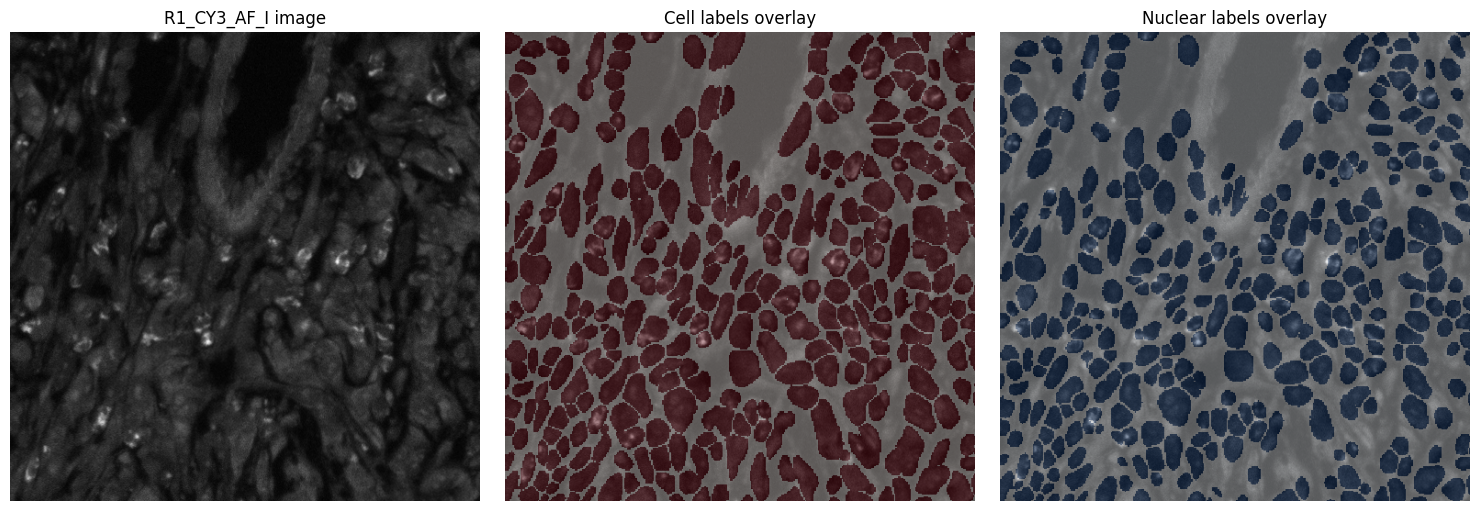

In [27]:
preview_channel = channel_aliases[0]
preview_image = scale0.sel(c=preview_channel).isel(y=slice(0, 512), x=slice(0, 512)).compute()
preview_cell_mask = cell_mask[:512, :512]
preview_nuclear_mask = nuclear_mask[:512, :512]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(preview_image, cmap="gray")
axes[0].set_title(f"{preview_channel} image")
axes[1].imshow(preview_image, cmap="gray")
axes[1].imshow(preview_cell_mask > 0, alpha=0.35, cmap="Reds")
axes[1].set_title("Cell labels overlay")
axes[2].imshow(preview_image, cmap="gray")
axes[2].imshow(preview_nuclear_mask > 0, alpha=0.35, cmap="Blues")
axes[2].set_title("Nuclear labels overlay")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout()


In [29]:
display(base_sdata)
print({
    "images": list(base_sdata.images.keys()),
    "labels": list(base_sdata.labels.keys()),
    "shapes": list(base_sdata.shapes.keys()),
    "tables": list(base_sdata.tables.keys()),
})


SpatialData object
├── Images
│     └── 'full_image': DataTree[cyx] (24, 2048, 2048), (24, 1024, 1024), (24, 512, 512), (24, 256, 256), (24, 128, 128), (24, 64, 64), (24, 32, 32), (24, 16, 16)
├── Labels
│     ├── 'cell_labels': DataArray[yx] (2048, 2048)
│     └── 'nuclear_labels': DataArray[yx] (2048, 2048)
├── Shapes
│     └── 'cell_boundaries': GeoDataFrame shape: (4439, 4) (2D shapes)
└── Tables
      └── 'nimbus_table': AnnData (4439, 4)
with coordinate systems:
    ▸ 'global', with elements:
        full_image (Images), cell_labels (Labels), nuclear_labels (Labels), cell_boundaries (Shapes)

{'images': ['full_image'], 'labels': ['cell_labels', 'nuclear_labels'], 'shapes': ['cell_boundaries'], 'tables': ['nimbus_table']}


In [30]:
base_sdata.write("test.zarr")

/home/ratnayn/miniconda3/envs/spatialdata/lib/python3.12/site-packages/ome_zarr/writer.py:319: FutureWarning: Passing storage-related arguments via **kwargs is deprecated. Please use the 'zarr_store_kwargs' parameter instead. **kwargs will be removed in a future version.
  da_delayed = da.to_zarr(
